# Tutorial 1 · From Python loops to orthonormal vectors
## 从变量变化，走到能验证的程序

[Lecture 1](Lecture01.md) · [数学补课](../../learning/foundation-notes/MathForML.md#projection) · [课程目录](README.md)

依据当前原Tutorial1的47个单元编写；单元号从1起算，不是In[n]。本文件是可运行参考讲解，例题答案是整理者实现。原课的Colab挂盘改为本地文件路径，练习输出写入独立目录。

原任务顺序：认识Notebook状态 → 数非平凡因子 → 折线图和直方图 → 读取数据 → Gram–Schmidt。先完整运行，再合上答案自己写一次。

| 原任务 | 优先级 | 难度与卡点 | 掌握要求与依据 |
|---|---|---|---|
| Tutorial1，第1–13个单元 Notebook与变量 | 核心必会 | 低，执行顺序 | 能从干净内核复现；当前原任务 |
| Tutorial1，第14–25个单元 因子与图 | 核心必会 | 中，循环范围和两种横轴 | 能独立实现并解释输出 |
| Tutorial1，第26–34个单元 数据文件 | 常规掌握 | 中，路径与数组轴 | 能读取、核对shape、画点 |
| Tutorial1，第35–45个单元 Gram–Schmidt | 核心必会 | 高，投影与张成空间 | 实现并检查正交、长度与空间保持 |
| Tutorial1，第46–47个单元 查帮助 | 常规掌握 | 低，工具用法 | 会查接口而非猜参数 |

优先级依据上列原任务。


## 0. Setup｜本地路径与输出位置
只在本节修改路径。例题新文件和图片放在本讲义输出目录，原件只读。
English: Configure paths here; generated files go to the learning-note output directory.

In [1]:
from pathlib import Path
import os
import json, pickle, pickletools, math
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
REPO = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p/'learning/course-notes-documents.json').is_file()), None)
if REPO is None:
    raise FileNotFoundError('Run this notebook from the CityU-StudyNotes checkout.')
COURSE = Path(os.environ.get('COURSE_DATA_ROOT', str(REPO/'data'))).expanduser().resolve()
DATA = COURSE/'CS5489/Lecture1/Tutorial/data1.pickle'
if not DATA.is_file():
    raise FileNotFoundError(f'Missing {DATA}; obtain the Canvas data and set COURSE_DATA_ROOT (see docs/DATA.md).')
NOTES = REPO/'CS5489/course-notes'
ASSETS = NOTES/'assets'; ASSETS.mkdir(exist_ok=True)
OUTPUT = NOTES/'outputs/Tutorial01'; OUTPUT.mkdir(parents=True,exist_ok=True)
SEED = 42
BLUE, GOLD = '#2878a5', '#bd7c20'
plt.rcParams.update({'figure.figsize':(6.4,4.2),'font.size':12,'axes.spines.top':False,'axes.spines.right':False})
print('Input:', DATA.relative_to(COURSE))

Input: CS5489/Lecture1/Tutorial/data1.pickle



## 1. Notebook state｜屏幕顺序不等于执行顺序
**原任务Tutorial1，第3–13个单元 / Task:** 运行单元、重复更新变量、重启内核观察状态。 / Run cells, repeat an update, and understand kernel restart.

`x=x+1`先读取旧x，再算右侧，最后把新值赋给x。以下把三次运行展开，保存清楚的状态轨迹。示例捕获NameError，便于继续观察后续单元。

In [2]:
x = 2
trace = []
for run in range(1,4):
    before = x
    x = x + 1
    trace.append({'Run':run,'Before x':before,'After x':x})
display(pd.DataFrame(trace))
try:
    _ = not_defined_in_this_kernel
except NameError:
    print('Expected teaching example: a name must be defined before it is read.')
assert x == 5

,Run,Before x,After x
0,1,2,3
1,2,3,4
2,3,4,5


Expected teaching example: a name must be defined before it is read.


**独立题 / Try:** 初始x=10，把`x=x*2`执行两次，得到多少？重启内核后直接运行这一行会怎样？ / Starting at x=10, execute x=x*2 twice. What happens if you restart the kernel and run only that line?

**答 / Answer:** 40；重启清除了变量，需重新定义x。 / 40; after restart x must be initialized again.


## 2. Count factors｜先写人能逐行跟上的版本
**原任务Tutorial1，第14–18个单元 / Task:** 对2到100的每个整数，统计除1和自身之外的正因子数。 / Count positive divisors excluding 1 and n for every integer n from 2 through 100.

对n=12，逐个试d=2,…,11；`n % d == 0`表示除后余数为0。2、3、4、6通过，得到4。`return`应在整个循环结束后执行，不能发现第一个因子就离开。

In [3]:
def count_factors(n):
    if not isinstance(n, (int,np.integer)) or n < 2:
        raise ValueError('n must be an integer at least 2')
    total = 0
    for d in range(2,n):
        if n % d == 0:
            total += 1
    return total
xs = np.arange(2,101)
fs = np.array([count_factors(int(n)) for n in xs])
assert (count_factors(2),count_factors(4),count_factors(12)) == (0,1,4)
assert len(xs) == 99
# Independent pair-of-divisors check, including perfect squares only once.
def paired_count(n):
    return sum(1 if d*d==n else 2 for d in range(2,math.isqrt(n)+1) if n%d==0)
assert np.array_equal(fs,[paired_count(int(n)) for n in xs])
print('12 has these non-trivial factors:', [d for d in range(2,12) if 12%d==0])
display(pd.DataFrame({'n':xs[:10], 'Non-trivial factors':fs[:10]}))

12 has these non-trivial factors: [2, 3, 4, 6]


,n,Non-trivial factors
0,2,0
1,3,0
2,4,1
3,5,0
4,6,2
5,7,0
6,8,2
7,9,1
8,10,2
9,11,0


**变式 / Transfer:** 不运行程序，求9和13的结果。 / Without running the program, find the counts for 9 and 13.
**答 / Answer:** 9只有3，得到1；13为素数，得到0。 / 9 has only divisor 3, giving 1; 13 is prime, giving 0.

第一张图问“每个数有几个因子”，第二张图问“有多少数落在某个因子数里”。两个横轴不是同一个东西。

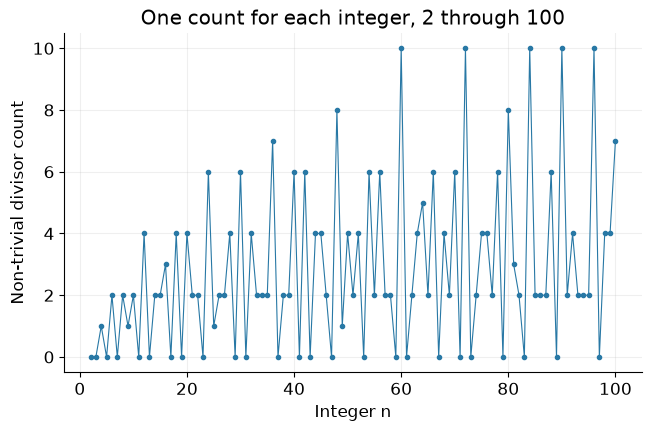

In [4]:
fig,ax=plt.subplots(layout='constrained')
ax.plot(xs,fs,'o-',color=BLUE,ms=3,lw=.8)
ax.set(xlabel='Integer n',ylabel='Non-trivial divisor count',title='One count for each integer, 2 through 100')
ax.grid(alpha=.2);fig.savefig(ASSETS/'tut01-factor-count.png',dpi=160);plt.show()

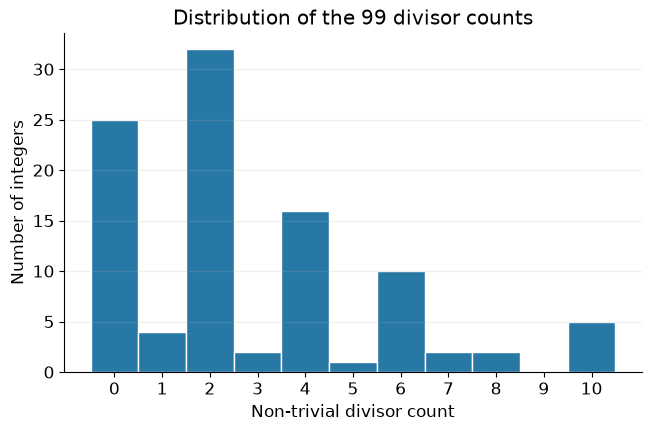

Total histogram frequency: 99


In [5]:
bins=np.arange(-.5,fs.max()+1.5,1)
frequencies,edges=np.histogram(fs,bins)
assert frequencies.sum()==99 and frequencies[0]==25
fig,ax=plt.subplots(layout='constrained')
ax.hist(fs,bins=bins,color=BLUE,edgecolor='white')
ax.set(xlabel='Non-trivial divisor count',ylabel='Number of integers',title='Distribution of the 99 divisor counts',xticks=np.arange(fs.max()+1))
ax.grid(axis='y',alpha=.2);fig.savefig(ASSETS/'tut01-factor-histogram.png',dpi=160);plt.show()
print('Total histogram frequency:',int(frequencies.sum()))

看图检查：0这一箱对应素数，共25个；所有箱合计99。原固定坐标范围对应本题，换输入范围后应重新检查是否截掉数据。
English: The zero bin contains the 25 primes in this range. Histogram counts total 99; fixed axis limits need reconsideration when the range changes.


## 3. Load and plot the supplied array｜先核对两根轴
**原任务Tutorial1，第26–34个单元 / Task:** 从原data1.pickle读入mydata，检查shape，画第1列对第2列。 / Load mydata, inspect its shape, and plot column 1 against column 2.

下面读取课程提供的NumPy数组文件。Pickle加载可能执行对象重建操作，因此这里只使用已知来源的课程文件。

Actual shape: (120, 2) dtype: float64


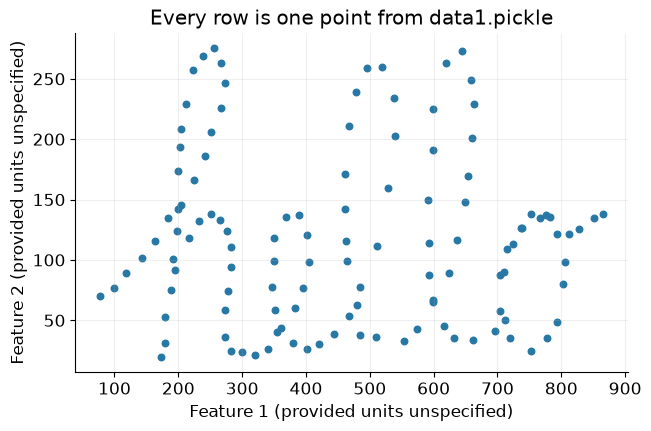

In [6]:
class ArrayOnlyUnpickler(pickle.Unpickler):
    def find_class(self,module,name):
        if module in ('numpy.core.multiarray','numpy._core.multiarray') and name=='_reconstruct':
            from numpy._core.multiarray import _reconstruct
            return _reconstruct
        if module=='numpy' and name in ('ndarray','dtype'):
            return getattr(np,name)
        raise pickle.UnpicklingError(f'Unexpected object type: {module}.{name}')
with DATA.open('rb') as f:
    mydata=ArrayOnlyUnpickler(f,encoding='latin1').load()
assert isinstance(mydata,np.ndarray) and mydata.ndim==2 and mydata.shape[1]==2
assert np.issubdtype(mydata.dtype,np.number) and np.isfinite(mydata).all()
print('Actual shape:',mydata.shape,'dtype:',mydata.dtype)
fig,ax=plt.subplots(layout='constrained')
ax.scatter(mydata[:,0],mydata[:,1],s=22,c=BLUE)
ax.set(xlabel='Feature 1 (provided units unspecified)',ylabel='Feature 2 (provided units unspecified)',title='Every row is one point from data1.pickle')
ax.grid(alpha=.2);fig.savefig(ASSETS/'tut01-data-scatter.png',dpi=160);plt.show()

`mydata[:,0]`选所有行的第0列，不是第一行。数据形状为120×2；原文件未给出类别标签或坐标的物理单位。
**自查 / Check:** `mydata[:3,:]`取什么？ / What does mydata[:3,:] select?
**答 / Answer:** 前三条样本的全部特征，形状(3,2)。 / All features of the first three samples, shape (3,2).

<a id="gram-schmidt"></a>

## 4. Gram–Schmidt｜拿走已有方向，剩下才是新信息
**原任务Tutorial1，第35–45个单元 / Task:** 输入矩阵V每列是一个向量，返回同一张成空间的正交归一列E。 / Return orthonormal columns spanning the same column space as V.

先补[长度、投影与张成空间](../../learning/foundation-notes/MathForML.md#projection)。例如v=(2,1)、u=(1,0)，投影到u方向是(2,0)，相减余下(0,1)。不是把所有向量分别除以长度就能让它们互相垂直。

对非零u，$P_u(v)=(v^Tu)/(u^Tu)\,u$。原步骤是从第k列减去已有各方向的投影，再归一化。下面存储单位方向q，因此投影简化为$(q^Tv)q$。这对应原课的classical Gram–Schmidt。数值接近线性相关时会更难稳定计算，后面的检查会帮助发现问题；其他QR算法可在二读时学习。

In [7]:
def myGS(V,rtol=1e-10):
    V=np.asarray(V,dtype=float)
    if V.ndim!=2 or V.shape[0]<V.shape[1] or not np.isfinite(V).all():
        raise ValueError('Need a finite tall or square 2-D matrix')
    scale=np.linalg.norm(V,ord=2)
    if scale==0:
        raise ValueError('Zero columns cannot define unit directions')
    E=np.zeros_like(V)
    for k in range(V.shape[1]):
        v=V[:,k]
        u=v.copy()
        for j in range(k):
            u -= np.dot(E[:,j],v)*E[:,j]
        length=np.linalg.norm(u)
        if length<=rtol*scale:
            raise ValueError('Columns are dependent or numerically too close to dependent')
        E[:,k]=u/length
    return E
V=np.array([[1.,0,-1,4],[-1,2,2,-1],[2,3,1,-3]]).T
before=V.copy(); E=myGS(V)
assert np.array_equal(V,before)
assert np.allclose(E.T@E,np.eye(3),atol=1e-10)
assert np.allclose(E@(E.T@V),V,atol=1e-10)
Q,_=np.linalg.qr(V,mode='reduced')
assert np.allclose(E@E.T,Q@Q.T,atol=1e-10)
try:
    myGS([[1,2],[2,4]])
except ValueError:
    print('Dependent-column test: explicitly rejected, no division by zero.')
else:
    raise AssertionError('Dependent columns were not rejected')
print('E shape:',E.shape)
display(pd.DataFrame(E).round(6))
print('Orthonormality error:',np.linalg.norm(E.T@E-np.eye(3)))
print('Span reconstruction error:',np.linalg.norm(E@(E.T@V)-V))

Dependent-column test: explicitly rejected, no division by zero.
E shape: (4, 3)


,0,1,2
0,0.235702,-0.226527,0.827393
1,0.000000,0.741362,0.468296
2,-0.235702,0.597209,-0.180599
3,0.942809,0.205934,-0.251998


Orthonormality error: 4.918300529807393e-16
Span reconstruction error: 1.7227701019713026e-15


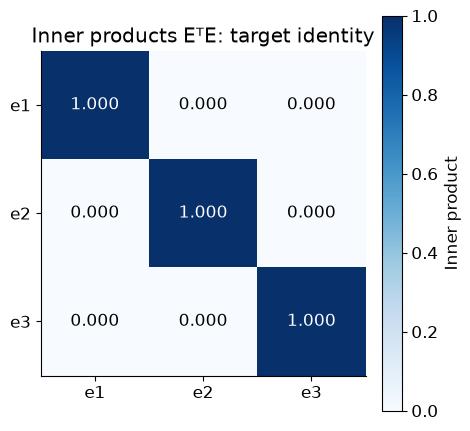

In [8]:
gram=E.T@E
fig,ax=plt.subplots(figsize=(4.6,4.2),layout='constrained')
im=ax.imshow(gram,vmin=0,vmax=1,cmap='Blues')
for i in range(3):
    for j in range(3):ax.text(j,i,f'{gram[i,j]:.3f}',ha='center',va='center',color='white' if i==j else 'black')
ax.set(xticks=range(3),yticks=range(3),xticklabels=['e1','e2','e3'],yticklabels=['e1','e2','e3'],title='Inner products EᵀE: target identity')
fig.colorbar(im,ax=ax,label='Inner product');fig.savefig(ASSETS/'tut01-gram.png',dpi=160);plt.show()

**输出解读 / Interpretation:** 对角线1表示单位长度，非对角线接近0表示正交；另一项重建检查才说明没有换成无关的子空间。 / Diagonal ones check unit lengths; near-zero off-diagonal entries check orthogonality. Reconstruction checks that the original span was retained.

**独立变式 / Transfer:** V的两列是(1,0)和(1,1)。手算E；如果第二列改成(2,0)又怎样？ / Hand-compute E for columns (1,0) and (1,1). What changes if the second column becomes (2,0)?
**答 / Answer:** 得到(1,0)、(0,1)；改后第二列残差为零，只提供一个方向，不能产生两个正交单位列。 / The basis is (1,0),(0,1). The replacement is dependent and yields a zero residual, so two unit directions cannot be produced.

In [9]:
result={'source':'Tutorial1.ipynb; data1.pickle','integer_range':[2,100],'integer_count':len(xs),'histogram_total':int(frequencies.sum()),'prime_count':int(frequencies[0]),'data_shape':list(mydata.shape),'gs_shape':list(E.shape),'gs_orthogonality_error':float(np.linalg.norm(E.T@E-np.eye(3))),'gs_span_error':float(np.linalg.norm(E@(E.T@V)-V)),'all_checks_passed':True}
(NOTES/'tutorial01-results.json').write_text(json.dumps(result,indent=2)+'\n')
display(pd.DataFrame({'Check':list(result),'Result':[str(v) for v in result.values()]}))

,Check,Result
0,source,Tutorial1.ipynb; data1.pickle
1,integer_range,"[2, 100]"
2,integer_count,99
3,histogram_total,99
4,prime_count,25
5,data_shape,"[120, 2]"
6,gs_shape,"[4, 3]"
7,gs_orthogonality_error,4.918300529807393e-16
8,gs_span_error,1.7227701019713026e-15
9,all_checks_passed,True



## 5. Help and return｜最后练一次英文解释
查询函数用法时，可用`help(myGS)`或Jupyter中的`myGS?`查看接口。来源：Tutorial1，第46–47个单元。调试先读异常最后一行和对应代码位置；重启并从头运行，能排除“旧变量碰巧还在”的情况。

**Q / 题：** Why is EᵀE=I not the only check? / 为什么只检查EᵀE=I还不够？
**A / 答：** An unrelated orthonormal basis can also pass it; check that E reconstructs every original column. / 无关的正交基也能通过，还要检查原列能由E重建。

[回Lecture1](Lecture01.md#linear-algebra) · [下一讲Lecture2](Lecture02.md) · [微课ML04](https://crazyshout.github.io/micro-course/?lesson=ml04)。按课程目录提供的已有卡号巩固，算法仍需独立重写。

## 原文件覆盖索引
| 原单元 | 本文件对应 |
|---|---|
| Tutorial1，第1–6个单元 | 标题、Setup；身份填空不代填，Colab改为本地路径 |
| Tutorial1，第7–13个单元 | §1状态轨迹与预期NameError |
| Tutorial1，第14–18个单元 | §2因子程序 |
| Tutorial1，第19–25个单元 | §2两幅原任务图 |
| Tutorial1，第26–34个单元 | §3数据读取、shape、散点 |
| Tutorial1，第35–45个单元 | §4投影、实现、原矩阵及三种检查 |
| Tutorial1，第46–47个单元 | §5帮助与收尾；Tutorial1，第47个单元为空单元 |